In [188]:
import torch
import numpy as np
import pandas as pd
import os 
import re
import torch.nn.functional as F 
import math
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence
from torch.optim import Adam
from torch.utils.tensorboard import SummaryWriter
from torch.nn.utils import clip_grad_norm_
from tensorflow import keras
from tqdm import tqdm
import time 
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
device = torch.device('cuda')
print(device)

cuda


In [2]:

def fill_down_excel_files(input_folder, output_folder=None):
    # Check if input folder exists
    if not os.path.exists(input_folder):
        print(f"Error: Input folder '{input_folder}' does not exist.")
        return

    # Create output folder if saving elsewhere
    if output_folder and not os.path.exists(output_folder):
        os.makedirs(output_folder)
        print(f"Output folder created: {output_folder}")

    files_processed = 0  # Track processed files

    for file in os.listdir(input_folder):
        if file.endswith(".xlsx") or file.endswith(".xls"):
            input_path = os.path.join(input_folder, file)

            try:
                # Read the file
                df = pd.read_excel(input_path)
                print(f"Processing: {file}")

                # Fill missing values
                df.fillna(method='ffill', inplace=True)

                # Set output path (either overwrite or to a new folder)
                if output_folder:
                    output_path = os.path.join(output_folder, file)
                else:
                    output_path = input_path  # overwrite original file

                # Save the processed file
                df.to_excel(output_path, index=False)
                print(f"Saved: {output_path}")
                files_processed += 1

            except Exception as e:
                print(f"Error processing file '{file}': {e}")

    if files_processed == 0:
        print("No files processed.")
    else:
        print(f"Finished processing {files_processed} files.")




In [3]:
# input_folder = "/root/labeldata"
# output_folder = "/root/labeldata_proc"

# fill_down_excel_files(input_folder, output_folder = output_folder)

In [4]:
def extract_task_number(task_code):
    # From 'F01 (20)' → '20'
    match = re.search(r'\((\d+)\)', task_code)
    return match.group(1) if match else None

def format_trial_id(trial_id):
    return f"{int(trial_id):02d}"

def get_sensor_filename(folder_id, task_num, trial_id):
    # SA06 → S06
    sensor_folder = "S" + folder_id[2:]
    return f"{sensor_folder}T{task_num}R{trial_id}.csv"

def map_labels_to_sensors(sensor_root, label_root):
    mappings = []

    for label_file in os.listdir(label_root):
        if not label_file.endswith('.xlsx'):  # Assuming label files are Excel format
            continue

        label_path = os.path.join(label_root, label_file)
        df = pd.read_excel(label_path)

        folder_id = label_file.split("_")[0]  # e.g., SA06

        for _, row in df.iterrows():
            task_num = extract_task_number(row['Task Code (Task ID)'])
            trial_id = format_trial_id(row['Trial ID'])

            if task_num is None:
                continue  # skip malformed rows

            sensor_file = get_sensor_filename(folder_id, task_num, trial_id)
            sensor_path = os.path.join(sensor_root, folder_id, sensor_file)

            # Append mapping including the label filename
            mappings.append({
                "sensor_path": sensor_path,
                "label_row": row,
                "label_filename": label_file
            })

    return mappings

def generate_no_fall_mappings(sensor_root):
    mappings = []

    valid_tasks = {f"{i:02d}" for i in range(1, 20)} | {"35", "36"}
    sensor_pattern = re.compile(r"^S\d+T(\d+)R\d+\.csv$")  # Capture Tyy

    for folder_name in os.listdir(sensor_root):
        folder_path = os.path.join(sensor_root, folder_name)

        if not os.path.isdir(folder_path):
            continue

        for filename in os.listdir(folder_path):
            if not filename.endswith('.csv'):
                continue

            match = sensor_pattern.match(filename)
            if not match:
                continue

            task_num = match.group(1)  # This is yy from Tyy
            if task_num not in valid_tasks:
                continue

            sensor_path = os.path.join(folder_path, filename)

            dummy_label_row = pd.Series({
                "Task Code (Task ID)": "NA", "Description" : "No Fall",
                "Trial ID": "N/A"
            })

            mappings.append({
                "sensor_path": sensor_path,
                "label_row": dummy_label_row,
                "label_filename": None
            })

    return mappings



In [5]:
sensor_root = "/root/sensor_data"
label_root = "/root/labeldata_proc"
labelled_mappings = map_labels_to_sensors(sensor_root, label_root)
unlabelled_mappings = generate_no_fall_mappings(sensor_root)
mappings = labelled_mappings + unlabelled_mappings

In [6]:
print(len(mappings))
print(mappings)

5075


[{'sensor_path': '/root/sensor_data/SA06/S06T20R01.csv', 'label_row': Task Code (Task ID)                                F01 (20)
Description            Forward fall when trying to sit down
Trial ID                                                  1
Fall_onset_frame                                        130
Fall_impact_frame                                       208
Name: 0, dtype: object, 'label_filename': 'SA06_label.xlsx'}, {'sensor_path': '/root/sensor_data/SA06/S06T20R02.csv', 'label_row': Task Code (Task ID)                                F01 (20)
Description            Forward fall when trying to sit down
Trial ID                                                  2
Fall_onset_frame                                        184
Fall_impact_frame                                       272
Name: 1, dtype: object, 'label_filename': 'SA06_label.xlsx'}, {'sensor_path': '/root/sensor_data/SA06/S06T20R03.csv', 'label_row': Task Code (Task ID)                                F01 (20)
Descript

In [7]:

def get_dataset_from_mappings(mappings):
    keyword_to_label = {
        "forward": 1,
        "backward": 2,
        "lateral": 3,
        "no fall": 0,
        "fall": 4  # generic fallback label
    }

    num_classes = len(keyword_to_label)
    dataset = []

    for entry in mappings:
        sensor_path = entry['sensor_path']
        label_row = entry['label_row']

        try:
            df = pd.read_csv(sensor_path)
        except FileNotFoundError:
            print(f"Missing sensor file: {sensor_path}")
            continue

        # Drop non-sensor columns
        df = df.drop(columns=["TimeStamp(s)", "FrameCounter"], errors='ignore')

        # Convert to tensor
        sensor_tensor = torch.tensor(df.values, dtype=torch.float32)

        # Extract label from 'Description'
        description = str(label_row.get("Description", "")).lower()

        matched_label = None
        for keyword, label in keyword_to_label.items():
            if keyword in description:
                matched_label = label
                break

        if matched_label is None:
            print(f"Couldn't find a valid label in: {description}")
            continue

        label_tensor = torch.tensor(matched_label, dtype=torch.long)

        dataset.append((sensor_tensor, label_tensor))

    return dataset

    

In [8]:
dataset = get_dataset_from_mappings(mappings)

In [9]:
print(dataset[0][0].shape)
print(dataset[0][1])
len(dataset)

torch.Size([536, 9])
tensor(1)


5075

In [10]:

from torch.nn.utils.rnn import pack_padded_sequence

class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes, dropout):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=False
        )
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, mask=None):
        if mask is not None:
            lengths = mask.sum(1).cpu() # Get sequence lengths from mask
            packed = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
            _, (hn, _) = self.lstm(packed)
        else:
            _, (hn, _) = self.lstm(x)
        out = self.fc(hn[-1])  # Use last hidden state of final layer
        return out


In [266]:
def train_model(
    model, train_loader, val_loader, optimizer, criterion, scheduler, num_epochs=10, lr=1e-4, 
    grad_clip=1.0, log_dir="runs/exp1", log_every=10, save_frequency=5, save_dir="checkpoints", device='cpu'
):
    print(device)

    # Prepare logging
    writer = SummaryWriter(log_dir)
    global_step = 0
    
    # Create checkpoint directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(num_epochs):
        model.train()
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        
        train_loss_total = 0
        train_correct = 0
        train_total = 0

        for batch_idx, (x, y) in enumerate(pbar):
            x = x.to(device)
            y = y.to(device)
            mask = None

            optimizer.zero_grad()
            output = model(x,mask)
            loss = criterion(output, y)
            loss.backward()

            if grad_clip:
                clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            # Accuracy tracking
            preds = torch.argmax(output, dim=1)
            train_correct += (preds == y).sum().item()
            train_total += y.size(0)
            train_loss_total += loss.item()

            # Logging
            writer.add_scalar("Train/Loss", loss.item(), global_step)
            writer.add_scalar("Train/LR", scheduler.get_last_lr()[0], global_step)
           
            if batch_idx % log_every == 0:
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        writer.add_scalar(f"Params/{name}_grad_norm", param.grad.norm().item(), global_step)
                    writer.add_scalar(f"Params/{name}_param_norm", param.data.norm().item(), global_step)

            global_step += 1

        scheduler.step()

        avg_train_loss = train_loss_total / len(train_loader)
        train_acc = train_correct / train_total
        writer.add_scalar("Train/Epoch_Loss", avg_train_loss, epoch)
        writer.add_scalar("Train/Accuracy", train_acc, epoch)

        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y, mask in val_loader:
                x = x.to(device)
                y = y.to(device)
                mask = mask.to(device)

                output = model(x)
                loss = criterion(output, y)
                val_loss += loss.item()

                preds = torch.argmax(output, dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct / total

        writer.add_scalar("Val/Loss", avg_val_loss, epoch)
        writer.add_scalar("Val/Accuracy", val_acc, epoch)

        print(f"Val Loss: {avg_val_loss:.4f} | Val Accuracy: {val_acc:.4f} | Train Accuracy: {train_acc:.4f}")

        # Save checkpoint
        if (epoch + 1) % save_frequency == 0:
            checkpoint_path = os.path.join(save_dir, f"checkpoint_epoch_{epoch+1}.pth")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'loss': loss.item(),
            }, checkpoint_path)
            print(f"Checkpoint saved at {checkpoint_path}")

    writer.close()


In [267]:
# 🔧 Model hyperparameters
input_dim = 9
hidden_dim = 32           # ↑ Increase hidden size for better capacity on timeseries
num_layers = 2              # Fine for now — could test 3 later
dropout = 0.3               # ↑ Increase dropout to reduce overfitting

num_classes = 5

# 🔧 Training hyperparameters
batch_size = 1             # ↓ Decrease batch size for better generalization on smaller datasets
num_epochs = 50             # ↑ Increase epochs since dataset is small, but with early stopping
learning_rate = 5e-4        # ↑ Slightly higher lr — LSTMs sometimes converge better at this
weight_decay = 1e-4         # Add small weight decay for regularization

scheduler_step_size = 10    # Adjust to be a bit later
scheduler_gamma = 0.5       # Less aggressive decay

max_seq_len = 5000          # Keep as is (or cap around 1500 if you notice long sequences adding noise)
      # Max padded sequence length (used for positional encoding in transformer, not needed here)

timestamp = time.strftime("%Y%m%d-%H%M%S")
checkpoint_dir = f'./checkpoints/run_{timestamp}'
save_frequency = 1
log_dir = f"runs/exp{timestamp}"
log_every = 200

# 🧠 Model instantiation (LSTM version)
model = LSTMClassifier(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes,
    dropout=dropout,
    
).to(device)

# ⚙️ Optimizer, Loss, Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=scheduler_step_size, gamma=scheduler_gamma)



In [268]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
from torch.nn.utils.rnn import pad_sequence
import torch

class TimeSeriesDataset(Dataset):
    def __init__(self, data, labels):
        assert len(data) == len(labels), "Data and labels must be same length"
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

def collate_fn(batch):
    xs, ys = zip(*batch)
    seq_lengths = [x.shape[0] for x in xs]
    padded_x = pad_sequence(xs, batch_first=True)
    mask = torch.zeros(padded_x.shape[:2], dtype=torch.bool)
    for i, length in enumerate(seq_lengths):
        mask[i, :length] = 1
    return padded_x, torch.tensor(ys), mask

# Assume dataset is a list of (tensor, label) pairs
data = [entry[0] for entry in dataset]
labels = [entry[1] for entry in dataset]
full_dataset = TimeSeriesDataset(data, labels)

# Split dataset first
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Compute class counts from training set only
train_labels = [train_dataset[i][1] for i in range(len(train_dataset))]
class_counts = torch.bincount(torch.tensor(train_labels))
class_weights = 1. / class_counts.float()

# Assign a weight to each sample in training set
sample_weights = torch.tensor([class_weights[label] for label in train_labels])

# Create the WeightedRandomSampler for training set
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, collate_fn=collate_fn)



In [269]:

counters = [0,0,0,0,0]
for y in labels: 
     counters[y.item()]+= 1
     
counters

[2729, 1247, 474, 473, 152]

In [270]:
train_model(model, train_loader, val_loader, optimizer, criterion, 
            scheduler, num_epochs,learning_rate, 
            save_dir = checkpoint_dir, save_frequency=save_frequency, device = device, log_dir=log_dir, log_every=log_every)

cuda


Epoch 1/50: 100%|██████████| 4060/4060 [00:10<00:00, 381.73it/s]


Val Loss: 0.6779 | Val Accuracy: 0.8363 | Train Accuracy: 0.7537
Checkpoint saved at ./checkpoints/run_20250504-234707/checkpoint_epoch_1.pth


Epoch 2/50: 100%|██████████| 4060/4060 [00:11<00:00, 355.84it/s]


Val Loss: 0.4664 | Val Accuracy: 0.9093 | Train Accuracy: 0.8810
Checkpoint saved at ./checkpoints/run_20250504-234707/checkpoint_epoch_2.pth


...

Val Loss: 0.3113 | Val Accuracy: 0.9467 | Train Accuracy: 0.9271
Checkpoint saved at ./checkpoints/run_20250504-234707/checkpoint_epoch_9.pth


Epoch 10/50: 100%|██████████| 4060/4060 [00:10<00:00, 381.15it/s]


Val Loss: 0.3902 | Val Accuracy: 0.9408 | Train Accuracy: 0.9244
Checkpoint saved at ./checkpoints/run_20250504-234707/checkpoint_epoch_10.pth


Epoch 11/50:  26%|██▌       | 1047/4060 [00:02<00:07, 379.26it/s]


KeyboardInterrupt: 

In [271]:
def test_model(model, test_loader, criterion, device='cpu'):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, y, mask in test_loader:
            x = x.to(device)
            y = y.to(device)
            mask = mask.to(device)

            output = model(x)
            loss = criterion(output, y)
            test_loss += loss.item()

            preds = torch.argmax(output, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

            all_preds.append(preds.cpu())
            all_targets.append(y.cpu())

    avg_loss = test_loss / len(test_loader)
    accuracy = correct / total

    print(f"\n🧪 Test Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.4f}")

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'predictions': torch.cat(all_preds),
        'targets': torch.cat(all_targets)
    }

In [272]:
test_results = test_model(model, test_loader, criterion, device='cuda')



🧪 Test Loss: 0.2410 | Test Accuracy: 0.9528


In [273]:


def plot_confusion_matrix(preds, targets, class_names=None, normalize=False, title='Confusion Matrix'):
    cm = confusion_matrix(targets, preds, normalize='true' if normalize else None)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, cmap='Blues', values_format=".2f" if normalize else "d")
    ax.set_title(title)
    plt.show()

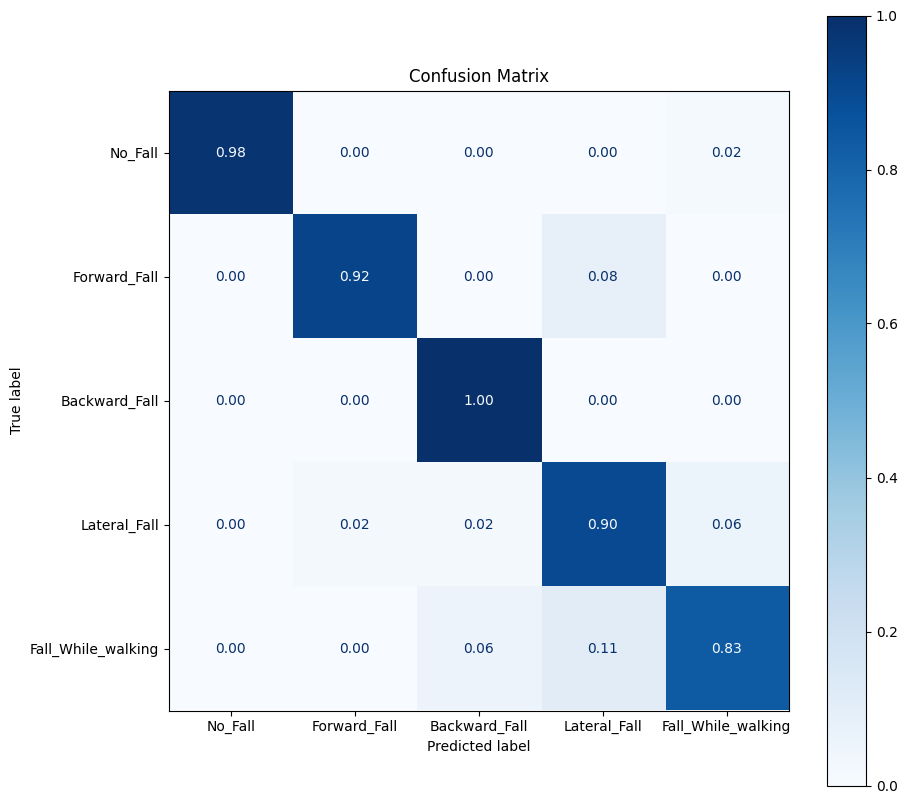

In [274]:
# Get raw predictions and targets
preds = test_results['predictions'].numpy()
targets = test_results['targets'].numpy()

# Optional: list your class labels if available
class_names = ['No_Fall', 'Forward_Fall', 'Backward_Fall', 'Lateral_Fall', 'Fall_While_walking']

# Plot it
plot_confusion_matrix(preds, targets, class_names=class_names, normalize=True)

In [275]:
load_path = "/root/checkpoints/run_20250504-234707/checkpoint_epoch_10.pth"
model

LSTMClassifier(
  (lstm): LSTM(9, 32, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=32, out_features=5, bias=True)
)

In [276]:
model.lstm


LSTM(9, 32, num_layers=2, batch_first=True, dropout=0.3)

In [277]:
# Load state dict
state_dict = torch.load(load_path, map_location="cpu")

# Inspect keys
print(state_dict.keys())

print(state_dict['model_state_dict'].keys())


dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'loss'])
odict_keys(['lstm.weight_ih_l0', 'lstm.weight_hh_l0', 'lstm.bias_ih_l0', 'lstm.bias_hh_l0', 'lstm.weight_ih_l1', 'lstm.weight_hh_l1', 'lstm.bias_ih_l1', 'lstm.bias_hh_l1', 'fc.weight', 'fc.bias'])


In [278]:

# Load checkpoint
checkpoint = torch.load(load_path, map_location="cpu")

# Get model weights only
model_state_dict = checkpoint['model_state_dict']

# Example: get LSTM layer 0 parameters
weight_ih_l0 = model_state_dict['lstm.weight_ih_l0'].numpy()
weight_hh_l0 = model_state_dict['lstm.weight_hh_l0'].numpy()
bias_ih_l0   = model_state_dict['lstm.bias_ih_l0'].numpy()
bias_hh_l0   = model_state_dict['lstm.bias_hh_l0'].numpy()

# Example: for FC layer
fc_weight = model_state_dict['fc.weight'].numpy()
fc_bias   = model_state_dict['fc.bias'].numpy()

In [279]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Disable GPU to prevent cuDNN usage during conversion
os.environ['CUDA_VISIBLE_DEVICES'] = ''  # Force CPU usage

def convert_pytorch_multilayer_lstm_to_keras(state_dict, input_size, hidden_size, num_layers, output_size=None):
    # Define Keras model using Functional API for single time step
    input_data = layers.Input(batch_shape=(1, 1, input_size), name='input')
    
    # Inputs for hidden and cell states for each LSTM layer
    state_inputs = []
    for i in range(num_layers):
        state_inputs.append([
            layers.Input(batch_shape=(1, hidden_size), name=f'hidden_state_{i}'),
            layers.Input(batch_shape=(1, hidden_size), name=f'cell_state_{i}')
        ])
    
    # Create LSTM layers with implementation=1 and unroll=True
    x = input_data
    new_states = []
    for i in range(num_layers):
        return_sequences = True if i < num_layers - 1 else False
        lstm_layer = layers.LSTM(hidden_size,
                                return_sequences=return_sequences,
                                return_state=True,
                                implementation=1,  # Force standard TensorFlow LSTM
                                unroll=True,      # Unroll for TFLite compatibility
                                name=f'lstm_{i}')
        x, h, c = lstm_layer(x, initial_state=state_inputs[i])
        new_states.append([h, c])
    
    # Add Dense layer with softmax
    if output_size is not None:
        x = layers.Dense(output_size, activation='softmax', name='dense')(x)
    
    # Define model
    outputs = [x] + [state for layer_states in new_states for state in layer_states]
    model = models.Model(
        inputs=[input_data] + [state for layer_states in state_inputs for state in layer_states],
        outputs=outputs
    )
    
    # Load PyTorch weights
    for i in range(num_layers):
        lstm_layer = model.get_layer(f'lstm_{i}')
        weight_ih = state_dict[f'lstm.weight_ih_l{i}'].cpu().numpy().T
        weight_hh = state_dict[f'lstm.weight_hh_l{i}'].cpu().numpy().T
        bias_ih = state_dict[f'lstm.bias_ih_l{i}'].cpu().numpy()
        bias_hh = state_dict[f'lstm.bias_hh_l{i}'].cpu().numpy()
        bias = bias_ih + bias_hh
        lstm_layer.set_weights([weight_ih, weight_hh, bias])
    
    if output_size is not None:
        fc_layer = model.get_layer('dense')
        fc_weight = state_dict['fc.weight'].cpu().numpy().T
        fc_bias = state_dict['fc.bias'].cpu().numpy()
        fc_layer.set_weights([fc_weight, fc_bias])
    
    return model

def convert_keras_to_tflite(keras_model, tflite_path):
    # Debug: Inspect model operations
    
   
    # Convert to TFLite with float16 inputs/outputs
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS
    ]
    # converter.inference_input_type = tf.float16  # Enforce float16 inputs
    # converter.inference_output_type = tf.float16  # Enforce float16 outputs
    converter.experimental_new_converter = True
    try:
        tflite_model = converter.convert()
    except Exception as e:
        print(f"TFLite conversion failed: {e}")
        raise
    
    # Save TFLite model
    with open(tflite_path, 'wb') as f:
        f.write(tflite_model)
    print(f"TFLite model saved to {tflite_path}")

In [280]:

# Example parameters (replace with your model's parameters)
input_size = 9
hidden_size = 32
num_layers = 2
output_size = 5

# Dummy state_dict for demonstration (replace with your PyTorch state_dict)
state_dict = model_state_dict 

# Convert PyTorch to Keras
keras_model = convert_pytorch_multilayer_lstm_to_keras(
    state_dict, input_size, hidden_size, num_layers, output_size
)

# Convert Keras to TFLite



In [281]:
keras_model.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (1, 1, 9)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_state_0      │ (1, 32)           │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cell_state_0        │ (1, 32)           │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_0 (LSTM)       │ [(1, 1, 32), (1,  │      5,376 │ input[0][0],      │
│                     │ 32), (1, 32)]     │            │ hidden_state_0[0… │
│                     │                   │            │ cell_state_0[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_state_1      │ (1, 32)           │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cell_state_1        │ (1, 32)           │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(1, 32), (1,     │      8,320 │ lstm_0[0][0],     │
│                     │ 32), (1, 32)]     │            │ hidden_state_1[0… │
│                     │                   │            │ cell_state_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (1, 5)            │        165 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,861 (54.14 KB)

 Trainable params: 13,861 (54.14 KB)

 Non-trainable params: 0 (0.00 B)

In [282]:
def compare_models(pytorch_model, keras_model, input_data, h0, c0):
    # PyTorch inference (model on GPU)
    pytorch_model.eval()
    with torch.no_grad():
        pytorch_output = pytorch_model(
            torch.tensor(input_data, dtype=torch.float32).cuda(),
            mask = None
        )
        pytorch_output = nn.functional.softmax(pytorch_output)
        pytorch_output = pytorch_output.cpu().numpy()
     
    
    # Keras inference
    keras_inputs = [input_data] + [h0[i] for i in range(len(h0))] + [c0[i] for i in range(len(c0))]
    keras_outputs = keras_model.predict(keras_inputs, verbose=0)
    keras_output = keras_outputs[0]

    
    # Compare outputs
    print("Output Comparison (PyTorch vs Keras):")
    print(f"PyTorch Output Shape: {pytorch_output.shape}, Keras Output Shape: {keras_output.shape}")
    output_diff = np.abs(pytorch_output - keras_output).max()
    print(f"Max Output Difference: {output_diff}")
    print(keras_output)
    print(pytorch_output)



In [284]:
# Prepare sample input and initial states
input_data = np.random.randn(1, 1, input_size).astype(np.float32)  # (batch, time_steps, input_size)
h0 = [np.zeros((1, hidden_size), dtype=np.float16) for _ in range(num_layers)]  # (num_layers, batch, hidden_size)
c0 = [np.zeros((1, hidden_size), dtype=np.float16) for _ in range(num_layers)]  # (num_layers, batch, hidden_size)

# Compare outputs
compare_models(model, keras_model, input_data, h0, c0)

Output Comparison (PyTorch vs Keras):
PyTorch Output Shape: (1, 5), Keras Output Shape: (1, 5)
Max Output Difference: 0.009826719760894775
[[0.14574616 0.25740355 0.18706664 0.21048354 0.19930011]]
[[0.14538656 0.26723027 0.18339652 0.2030109  0.20097573]]


/tmp/ipykernel_20493/72629114.py:9: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  pytorch_output = nn.functional.softmax(pytorch_output)


In [285]:
tf_lite_path = "/root/tflite/model.tflite"


In [286]:
convert_keras_to_tflite(keras_model, tf_lite_path)

INFO:tensorflow:Assets written to: /tmp/tmpr2heaup6/assets


INFO:tensorflow:Assets written to: /tmp/tmpr2heaup6/assets


Saved artifact at '/tmp/tmpr2heaup6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(1, 1, 9), dtype=tf.float32, name='input'), TensorSpec(shape=(1, 32), dtype=tf.float32, name='hidden_state_0'), TensorSpec(shape=(1, 32), dtype=tf.float32, name='cell_state_0'), TensorSpec(shape=(1, 32), dtype=tf.float32, name='hidden_state_1'), TensorSpec(shape=(1, 32), dtype=tf.float32, name='cell_state_1')]
Output Type:
  List[TensorSpec(shape=(1, 5), dtype=tf.float32, name=None), TensorSpec(shape=(1, 32), dtype=tf.float32, name=None), TensorSpec(shape=(1, 32), dtype=tf.float32, name=None), TensorSpec(shape=(1, 32), dtype=tf.float32, name=None), TensorSpec(shape=(1, 32), dtype=tf.float32, name=None)]
Captures:
  128988266906192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128988267281424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128988267276848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128988267281952: Ten

W0000 00:00:1746383138.619857   20493 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1746383138.619873   20493 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-05-04 23:55:38.620015: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpr2heaup6
2025-05-04 23:55:38.620539: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-05-04 23:55:38.620546: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpr2heaup6
2025-05-04 23:55:38.625526: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-05-04 23:55:38.649566: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpr2heaup6
2025-05-04 23:55:38.658819: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 38806 microseconds.
2025-05-04 23:55:38.730230: I tensorflow/comp

In [289]:
import os
import numpy as np
import tensorflow as tf

# Disable GPU to avoid CUDA warnings
os.environ['CUDA_VISIBLE_DEVICES'] = ''

def run_tflite_inference(model_path, input_data, hidden_states, cell_states):
    """
    Run inference on a TFLite model.
    
    Args:
        model_path (str): Path to the TFLite model file.
        input_data (np.ndarray): Input data of shape (1, 1, 9).
        hidden_states (list): List of hidden states [(1, 128), (1, 128)] for 2 LSTM layers.
        cell_states (list): List of cell states [(1, 128), (1, 128)] for 2 LSTM layers.
    
    Returns:
        dict: Dictionary containing prediction and new LSTM states.
    """
    # Validate inputs
    if input_data.shape != (1, 1, 9):
        raise ValueError(f"Expected input_data shape (1, 1, 9), got {input_data.shape}")
    if len(hidden_states) != 2 or len(cell_states) != 2:
        raise ValueError("Expected 2 hidden and 2 cell states for 2 LSTM layers")
    for i, (h, c) in enumerate(zip(hidden_states, cell_states)):
        if h.shape != (1, 32) or c.shape != (1,32):
            raise ValueError(f"Expected state shape (1, 128) for layer {i}, got h={h.shape}, c={c.shape}")

    # Load TFLite model
    try:
        interpreter = tf.lite.Interpreter(model_path=model_path)
        interpreter.allocate_tensors()
    except Exception as e:
        raise RuntimeError(f"Failed to load TFLite model: {e}")

    # Get input and output details
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Print details for debugging
    print("Input Details:")
    for d in input_details:
        print(f"  {d['name']}: shape={d['shape']}, dtype={d['dtype']}")
    print("Output Details:")
    for i, d in enumerate(output_details):
        print(f"  {i}: shape={d['shape']}, dtype={d['dtype']}")

    # Verify input details
    expected_inputs = 5  # 1 data + 2 hidden + 2 cell states
    if len(input_details) != expected_inputs:
        raise ValueError(f"Expected {expected_inputs} input tensors, got {len(input_details)}")

    # Set input tensors (float32)
    interpreter.set_tensor(input_details[0]['index'], input_data.astype(np.float32))
    for i in range(2):
        interpreter.set_tensor(input_details[1 + i*2]['index'], hidden_states[i].astype(np.float32))
        interpreter.set_tensor(input_details[2 + i*2]['index'], cell_states[i].astype(np.float32))

    # Run inference
    try:
        interpreter.invoke()
    except Exception as e:
        raise RuntimeError(f"Inference failed: {e}")

    # Find the (1, 5) output tensor (softmax prediction)
    prediction_idx = None
    for i, d in enumerate(output_details):
        if d['shape'].tolist() == [1, 5]:
            prediction_idx = i
            break
    if prediction_idx is None:
        raise ValueError("No output tensor with shape (1, 5) found")

    # Get outputs
    prediction = interpreter.get_tensor(output_details[prediction_idx]['index'])  # (1, 5)
    new_hidden_states = [
        interpreter.get_tensor(output_details[(i*2 + 1) % len(output_details)]['index']) for i in range(2)  # (1, 128)
    ]
    new_cell_states = [
        interpreter.get_tensor(output_details[(i*2 + 2) % len(output_details)]['index']) for i in range(2)  # (1, 128)
    ]

    # Validate softmax output
    if not np.all(prediction >= 0) or not np.all(prediction <= 1) or not np.isclose(np.sum(prediction), 1.0, rtol=1e-3):
        print("Warning: Prediction is not a valid softmax output")

    return {
        'prediction': prediction,
        'new_hidden_states': new_hidden_states,
        'new_cell_states': new_cell_states
    }

if __name__ == "__main__":
    # Model and input parameters
    model_path = "/root/tflite/model.tflite"
    
    try:
        # Generate synthetic input data
        input_data = np.random.randn(1, 1, 9).astype(np.float32)  # Random data
        # Alternative: fixed data for reproducibility
        # input_data = np.array([[[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]]], dtype=np.float32)
        
        # Initialize LSTM states
        hidden_states = [np.zeros((1, 32), dtype=np.float32) for _ in range(2)]
        cell_states = [np.zeros((1, 32), dtype=np.float32) for _ in range(2)]
        
        # Run inference
        results = run_tflite_inference(model_path, input_data, hidden_states, cell_states)
        
        # Print results
        print("Softmax Prediction:", results['prediction'])
        print("Predicted Class:", np.argmax(results['prediction']))
        
        # Optionally print new states (uncomment for debugging)
        # for i, (h, c) in enumerate(zip(results['new_hidden_states'], results['new_cell_states'])):
        #     print(f"Layer {i} New Hidden State Shape:", h.shape)
        #     print(f"Layer {i} New Cell State Shape:", c.shape)
        
    except Exception as e:
        print(f"Error: {e}")

Input Details:
  serving_default_input:0: shape=[1 1 9], dtype=<class 'numpy.float32'>
  serving_default_cell_state_1:0: shape=[ 1 32], dtype=<class 'numpy.float32'>
  serving_default_hidden_state_0:0: shape=[ 1 32], dtype=<class 'numpy.float32'>
  serving_default_hidden_state_1:0: shape=[ 1 32], dtype=<class 'numpy.float32'>
  serving_default_cell_state_0:0: shape=[ 1 32], dtype=<class 'numpy.float32'>
Output Details:
  0: shape=[ 1 32], dtype=<class 'numpy.float32'>
  1: shape=[ 1 32], dtype=<class 'numpy.float32'>
  2: shape=[ 1 32], dtype=<class 'numpy.float32'>
  3: shape=[1 5], dtype=<class 'numpy.float32'>
  4: shape=[ 1 32], dtype=<class 'numpy.float32'>
Softmax Prediction: [[0.13484833 0.26137018 0.1885966  0.22293481 0.1922501 ]]
Predicted Class: 1
